# Florida barrier-construction event study — panel descriptive statistics

**Source.** `data/florida/panel/assembled/event_study_panel.parquet`, built by
`python -m src.cli florida data panel assemble`
(`src/regions/florida/sources/panel/assemble.py`). It joins:

- **assessments** (outcome) — school x grade x subject x year test scores, standardised to `z_mss`,
- **schools** (spine) — Cluster-A covariates and static identity/filter fields,
- **schools assemble's rollup** — three parallel barrier-treatment-timing definitions
  (`point` / `same_route` / `same_side`, increasing matching rigour).

**This notebook** describes the assembled panel *as data* — shape, coverage, the outcome
distribution, covariate completeness, treatment-timing structure — the numbers an analysis
spec conditions on. It does not re-derive or justify any preprocessing choice; for the
intuition and diagnostics behind *why* each source looks the way it does, see the
`src/experiments/florida/` notebooks:

- [`assessments.ipynb`](../../../src/experiments/florida/assessments.ipynb) — score parsing,
  suppression, the FSA→FAST/B.E.S.T. scale break, the within-cell z-score,
- [`barriers.ipynb`](../../../src/experiments/florida/barriers.ipynb) — inventory cleaning,
  school-barrier proximity features,
- [`road_network.ipynb`](../../../src/experiments/florida/road_network.ipynb) — roadway
  centreline source, milepost continuity,
- [`schools.ipynb`](../../../src/experiments/florida/schools.ipynb) — spine construction,
  Cluster-A covariates, the point / same-route / same-side matching-algorithm design.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

warnings.filterwarnings("ignore", message="Measured .* geometry types are not supported")

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)


def repo_root(start: Path | None = None) -> Path:
    """Walk up until we find the checkout (has both src/ and data/)."""
    p = (start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "src").is_dir() and (c / "data").is_dir():
            return c
    raise FileNotFoundError(f"repo root not found from {Path.cwd()}")


ROOT = repo_root()
PANEL_PATH = ROOT / "data/florida/panel/assembled/event_study_panel.parquet"
FIGDIR = ROOT / "output/figures/florida"
FIGDIR.mkdir(parents=True, exist_ok=True)
assert PANEL_PATH.exists(), f"{PANEL_PATH} missing — run `python -m src.cli florida data panel assemble` first"

CRS_M = 3087
CRS_TILE = 3857
BASEMAP_LIGHT = cx.providers.Esri.WorldGrayCanvas


def add_basemap(ax, crs=CRS_M, source=BASEMAP_LIGHT, **kw):
    cx.add_basemap(ax, crs=crs, source=source, attribution_size=6, **kw)


def savefig(fig, name):
    path = FIGDIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print("wrote", path.relative_to(ROOT))


ROOT


PosixPath('/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution')

## 1. Load & grain

In [2]:
panel = gpd.read_parquet(PANEL_PATH)
print("shape:", panel.shape)
print("CRS  :", panel.crs.to_epsg())

grain_cols = ["msid", "grade", "subject", "year"]
dupes = panel.duplicated(grain_cols).sum()
print(f"duplicate {tuple(grain_cols)} keys:", dupes)
print("distinct schools:", panel["msid"].nunique())
print("year range:", int(panel["year"].min()), "-", int(panel["year"].max()))

panel.head(3)


shape: (370891, 90)
CRS  : 3087
duplicate ('msid', 'grade', 'subject', 'year') keys: 0
distinct schools: 4419
year range: 2015 - 2026


,msid,grade,subject,year,subject_label,regime,retrofitted_2015,district_number,district_name,school_number,school_name,is_state_total,suppressed,n_students,mean_scale_score,pct_level3_plus,pct_l1,pct_l2,pct_l3,pct_l4,pct_l5,z_mss,z_mss_w,source_file,in_operation,in_assessments,in_operation_src,ncessch,enrollment,enrollment_missing,frpl_n,frpl_n_missing,teachers_fte,teachers_fte_missing,title_i_status,ccd_charter,ccd_magnet,ccd_virtual,ccd_status,ccd_grade_low,...,swd_n,crdc_total,pct_swd,pct_ell,read_prof_midpt,math_prof_midpt,msid_school_name,msid_district_name,school_type,is_regular,is_alternative,is_charter,is_magnet,is_virtual,grade_low,grade_high,serves_tested_grades,geometry,nearest_fdot_dist_m,nearest_fdot_gcid,n_walls_100m,n_walls_200m,n_walls_300m,n_walls_500m,n_walls_1000m,wall_len_500m,ever_near_wall_500m,ever_near_wall_1000m,first_treat_year_point,ever_treated_point,timing_unknown_point,first_treat_year_same_route,ever_treated_same_route,timing_unknown_same_route,first_treat_year_same_side,ever_treated_same_side,timing_unknown_same_side,event_time_point,event_time_same_route,event_time_same_side
0,010021,03,ELA,2015,English Language Arts,FSA,True,01,ALACHUA,0021,CHARLES W. DUVAL ELEM SCHOOL,False,False,40,284,15,43,43,13,3,0,-1.670632,-1.824753,FL2015_ELA_G03_school.xls,True,True,dates+tested,120003000001,217.0,ok,181.0,ok,23.0,ok,5,0,1,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,CHARLES W. DUVAL ELEMENTARY SCHOOL,ALACHUA,elementary,True,False,False,True,False,0,5,True,POINT (564559.189 629343.07),57015.7,726.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,NaN,False,False,NaN,False,False,NaN,False,False,NaN,NaN,NaN
1,010021,03,MATH,2015,Mathematics,FSA,True,01,ALACHUA,0021,CHARLES W. DUVAL ELEM SCHOOL,False,False,40,284,18,53,30,15,3,0,-1.738755,-1.901004,FL2015_MATH_G03_school.xls,True,True,dates+tested,120003000001,217.0,ok,181.0,ok,23.0,ok,5,0,1,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,CHARLES W. DUVAL ELEMENTARY SCHOOL,ALACHUA,elementary,True,False,False,True,False,0,5,True,POINT (564559.189 629343.07),57015.7,726.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,NaN,False,False,NaN,False,False,NaN,False,False,NaN,NaN,NaN
2,010021,04,ELA,2015,English Language Arts,FSA,True,01,ALACHUA,0021,CHARLES W. DUVAL ELEM SCHOOL,False,False,34,301,32,47,21,24,9,0,-1.157302,-1.339638,FL2015_ELA_G04_school.xls,True,True,dates+tested,120003000001,217.0,ok,181.0,ok,23.0,ok,5,0,1,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,CHARLES W. DUVAL ELEMENTARY SCHOOL,ALACHUA,elementary,True,False,False,True,False,0,5,True,POINT (564559.189 629343.07),57015.7,726.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,NaN,False,False,NaN,False,False,NaN,False,False,NaN,NaN,NaN


370,891 rows on `(msid, grade, subject, year)` with no duplicate keys — the join in
`panel/assemble.py` is a clean `m:1` merge of covariates and treatment onto the
assessments grain, as designed. 4,419 distinct schools ever appear, spanning the eleven
spring administrations 2015-2026 (2020 excluded — no spring testing).

## 2. Coverage: subjects, grades, regimes

wrote output/figures/florida/panel_coverage_subject_grade_regime.png


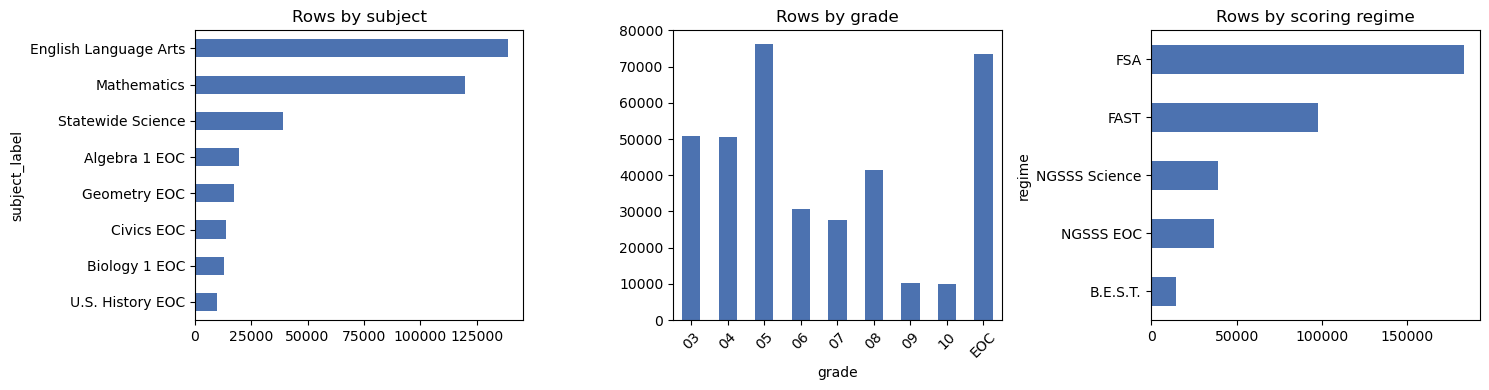

suppressed share: 0.1028


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

panel["subject_label"].value_counts().plot.barh(ax=axes[0], color="#4c72b0")
axes[0].set_title("Rows by subject")
axes[0].invert_yaxis()

panel["grade"].value_counts().sort_index().plot.bar(ax=axes[1], color="#4c72b0")
axes[1].set_title("Rows by grade")
axes[1].tick_params(axis="x", rotation=45)

panel["regime"].value_counts().plot.barh(ax=axes[2], color="#4c72b0")
axes[2].set_title("Rows by scoring regime")
axes[2].invert_yaxis()

fig.tight_layout()
savefig(fig, "panel_coverage_subject_grade_regime.png")
plt.show()

print("suppressed share:", round(panel['suppressed'].mean(), 4))


ELA and Math dominate the row count (elementary/middle grades tested every year); the
five EOCs are thinner and grade-specific by construction (one high-school course each).
About 10.3% of rows are suppressed (`n < 10/20`, no score) — carried through from
`assessments.ipynb`'s coverage analysis; suppressed rows still contribute to the panel's
covariate/treatment columns, just not to `z_mss`.

## 3. Outcome: `z_mss`

count    332778.0
mean         -0.0
std      0.999654
min     -5.940376
25%     -0.652671
50%      0.021497
75%      0.687545
max      4.494733
Name: z_mss, dtype: Float64


wrote output/figures/florida/panel_z_mss_distribution.png


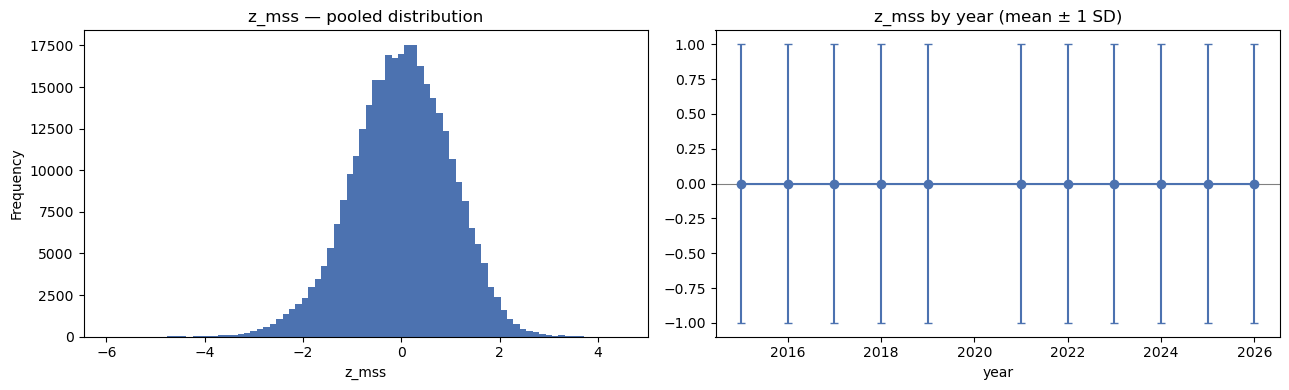

In [4]:
print(panel["z_mss"].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

panel["z_mss"].dropna().plot.hist(bins=80, ax=axes[0], color="#4c72b0")
axes[0].set_title("z_mss — pooled distribution")
axes[0].set_xlabel("z_mss")

yearly = panel.groupby("year")["z_mss"].agg(["mean", "std", "count"])
axes[1].errorbar(yearly.index, yearly["mean"], yerr=yearly["std"], fmt="o-", color="#4c72b0", capsize=3)
axes[1].axhline(0, color="grey", lw=0.8)
axes[1].set_title("z_mss by year (mean ± 1 SD)")
axes[1].set_xlabel("year")

fig.tight_layout()
savefig(fig, "panel_z_mss_distribution.png")
plt.show()


By construction (`assessments.ipynb` §4) `z_mss` is mean 0, SD ≈ 1 within every
`year × subject × grade` cell, and that holds up pooled across the whole panel with no
drift by year — the regime-change standardisation the source notebook validated survives
the join intact. 332,778 of 370,891 rows carry a score (the remainder is the suppressed
10.3% plus a handful of edge cases).

## 4. Cluster-A covariates: completeness & distributions

In [5]:
covariate_cols = [
    "enrollment", "frpl_n", "teachers_fte", "pupil_teacher_ratio",
    "pct_white", "pct_black", "pct_hispanic", "pct_asian",
    "pct_swd", "pct_ell", "read_prof_midpt", "math_prof_midpt",
]
missing = panel[covariate_cols].isna().mean().sort_values(ascending=False)
missing.to_frame("share_missing")


,share_missing
math_prof_midpt,0.664548
read_prof_midpt,0.663443
pct_ell,0.646384
pct_swd,0.646384
pupil_teacher_ratio,0.146396
teachers_fte,0.121702
frpl_n,0.107660
pct_asian,0.100183
pct_black,0.100183
pct_hispanic,0.100183


`read_prof_midpt` / `math_prof_midpt` and `pct_swd` / `pct_ell` are missing on ~65% of
rows — those four are CRDC fields reported only on CRDC's own (sparser, biennial)
collection cycle, not annually like CCD enrollment. Core CCD covariates (`enrollment`,
race/ethnicity shares, `frpl_n`) sit at 10-15% missing, tracking CCD's own non-reporting
rather than anything the panel join introduces.

wrote output/figures/florida/panel_covariate_distributions.png


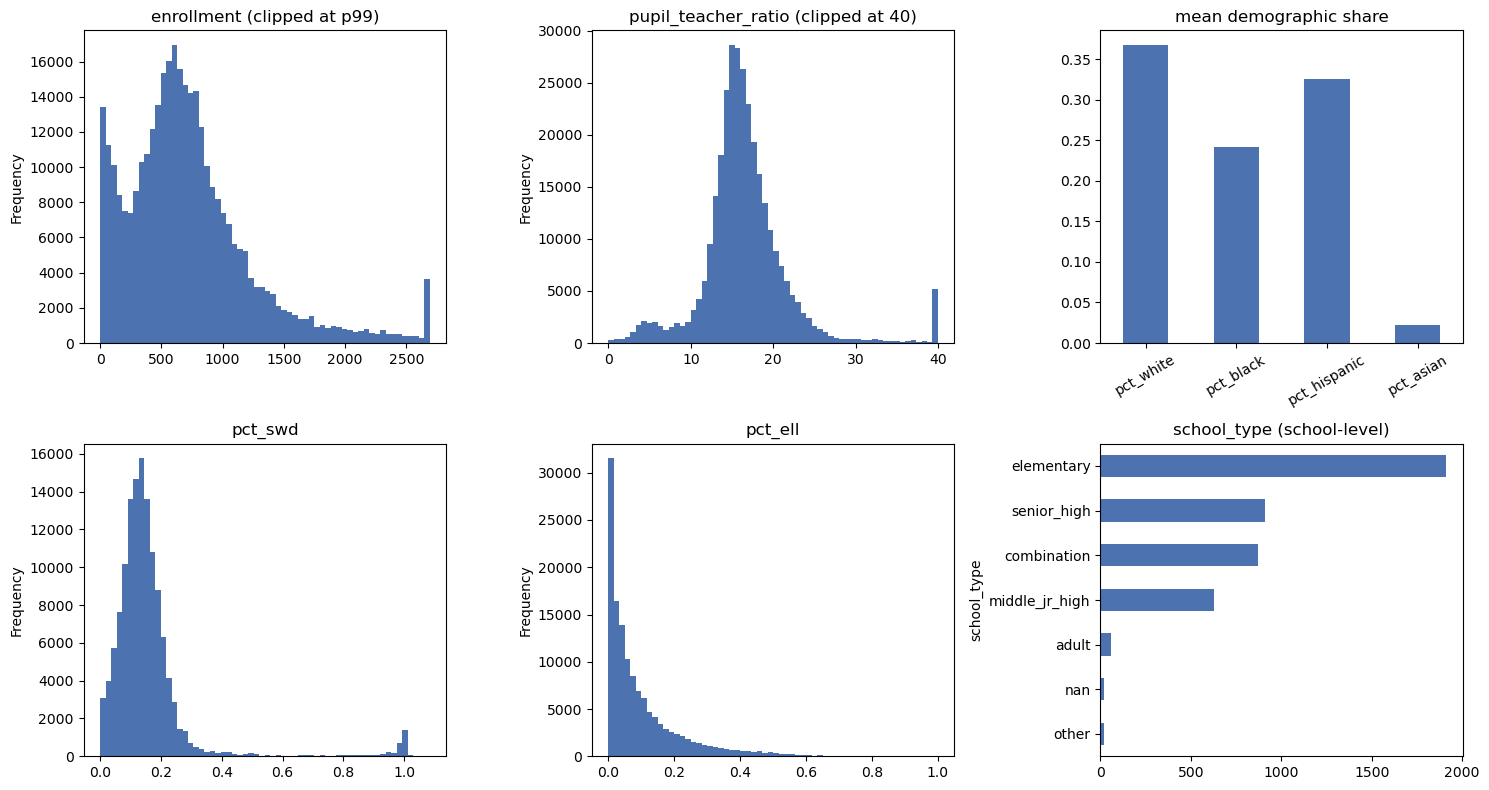

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

panel["enrollment"].dropna().clip(upper=panel["enrollment"].quantile(0.99)).plot.hist(
    bins=60, ax=axes[0, 0], color="#4c72b0")
axes[0, 0].set_title("enrollment (clipped at p99)")

panel["pupil_teacher_ratio"].dropna().clip(upper=40).plot.hist(bins=60, ax=axes[0, 1], color="#4c72b0")
axes[0, 1].set_title("pupil_teacher_ratio (clipped at 40)")

race_cols = ["pct_white", "pct_black", "pct_hispanic", "pct_asian"]
panel[race_cols].mean().plot.bar(ax=axes[0, 2], color="#4c72b0")
axes[0, 2].set_title("mean demographic share")
axes[0, 2].tick_params(axis="x", rotation=30)

panel["pct_swd"].dropna().plot.hist(bins=60, ax=axes[1, 0], color="#4c72b0")
axes[1, 0].set_title("pct_swd")

panel["pct_ell"].dropna().plot.hist(bins=60, ax=axes[1, 1], color="#4c72b0")
axes[1, 1].set_title("pct_ell")

sc = panel.drop_duplicates("msid")
sc["school_type"].value_counts(dropna=False).plot.barh(ax=axes[1, 2], color="#4c72b0")
axes[1, 2].set_title("school_type (school-level)")
axes[1, 2].invert_yaxis()

fig.tight_layout()
savefig(fig, "panel_covariate_distributions.png")
plt.show()


## 5. Treatment structure: point / same_route / same_side

In [7]:
definitions = ["point", "same_route", "same_side"]
rows = []
for d in definitions:
    et = panel[f"ever_treated_{d}"]
    rows.append({
        "definition": d,
        "ever_treated_schools": panel.loc[et, "msid"].nunique(),
        "ever_treated_rows": int(et.sum()),
        "timing_unknown_rows": int(panel[f"timing_unknown_{d}"].sum()),
    })
summary = pd.DataFrame(rows).set_index("definition")
summary


,ever_treated_schools,ever_treated_rows,timing_unknown_rows
definition,,,
point,455,39017,1535
same_route,262,21972,481
same_side,198,17004,447


The three definitions nest as designed: `same_route` ⊆ `point` and `same_side` ⊆
`same_route` (checked below) — each tier adds a stricter geometric requirement
(`schools.ipynb` §7) on top of the last, so tightening the match only removes schools, it
never adds a different set.

In [8]:
schools_by_def = {
    d: set(panel.loc[panel[f"ever_treated_{d}"], "msid"].unique()) for d in definitions
}
print("same_route subset of point:      ", schools_by_def["same_route"] <= schools_by_def["point"])
print("same_side subset of same_route:  ", schools_by_def["same_side"] <= schools_by_def["same_route"])
print("point-only (dropped by same_route):", len(schools_by_def["point"] - schools_by_def["same_route"]))
print("same_route-only (dropped by same_side):", len(schools_by_def["same_route"] - schools_by_def["same_side"]))


same_route subset of point:       True
same_side subset of same_route:   True
point-only (dropped by same_route): 193
same_route-only (dropped by same_side): 64


### Treatment timing vs. the panel window

`first_treat_year` is a wall's **construction** year — many barriers pre-date the
assessment panel (2015-2026) entirely. A school whose nearest wall went up in, say, 1998
is treated in every panel year: it contributes no pre-period and cannot identify an
event-time effect on its own. Splitting ever-treated schools by whether `first_treat_year`
falls inside the panel window is the key design fact for choosing an estimation sample.

In [9]:
rows = []
for d in definitions:
    sc = panel.drop_duplicates("msid")
    et = sc[sc[f"ever_treated_{d}"]]
    known = et[~et[f"timing_unknown_{d}"]]
    pre_panel = (known[f"first_treat_year_{d}"] < 2015).sum()
    in_window = known[f"first_treat_year_{d}"].between(2015, 2026).sum()
    rows.append({
        "definition": d,
        "ever_treated": len(et),
        "timing_known": len(known),
        "first_treat_before_2015 (always-treated in-sample)": pre_panel,
        "first_treat_in_2015-2026 (usable event variation)": in_window,
    })
pd.DataFrame(rows).set_index("definition")


,ever_treated,timing_known,first_treat_before_2015 (always-treated in-sample),first_treat_in_2015-2026 (usable event variation)
definition,,,,
point,455,436,295,141
same_route,262,255,178,77
same_side,198,193,130,63


wrote output/figures/florida/panel_first_treat_year_distribution.png


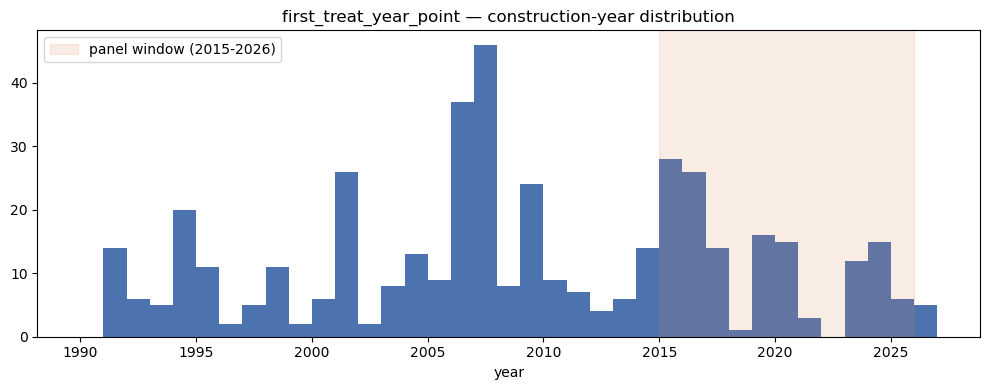

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
sc = panel.drop_duplicates("msid")
years = sc.loc[sc["ever_treated_point"] & ~sc["timing_unknown_point"], "first_treat_year_point"]
ax.hist(years, bins=range(1990, 2028), color="#4c72b0")
ax.axvspan(2015, 2026, color="#dd8452", alpha=0.15, label="panel window (2015-2026)")
ax.set_title("first_treat_year_point — construction-year distribution")
ax.set_xlabel("year")
ax.legend()
fig.tight_layout()
savefig(fig, "panel_first_treat_year_distribution.png")
plt.show()


Under the loosest definition (`point`), only 141 of 455 ever-treated schools (31%) have
their nearest wall built *within* the panel window — the other 295 are always-treated
in-sample. The share shrinks further under the stricter definitions (77/262 for
`same_route`, 63/198 for `same_side`), since tightening the match disproportionately drops
schools with more recent, more precisely-matched construction. An event-study spec has a
real, and definition-dependent, ceiling on how many schools carry identifying variation —
this is not a data-quality issue, it reflects when Florida actually built its highway
noise barriers relative to when FLDOE assessment data starts.

## 6. Geography: treated vs. never-treated schools

wrote output/figures/florida/panel_treated_schools_statewide.png


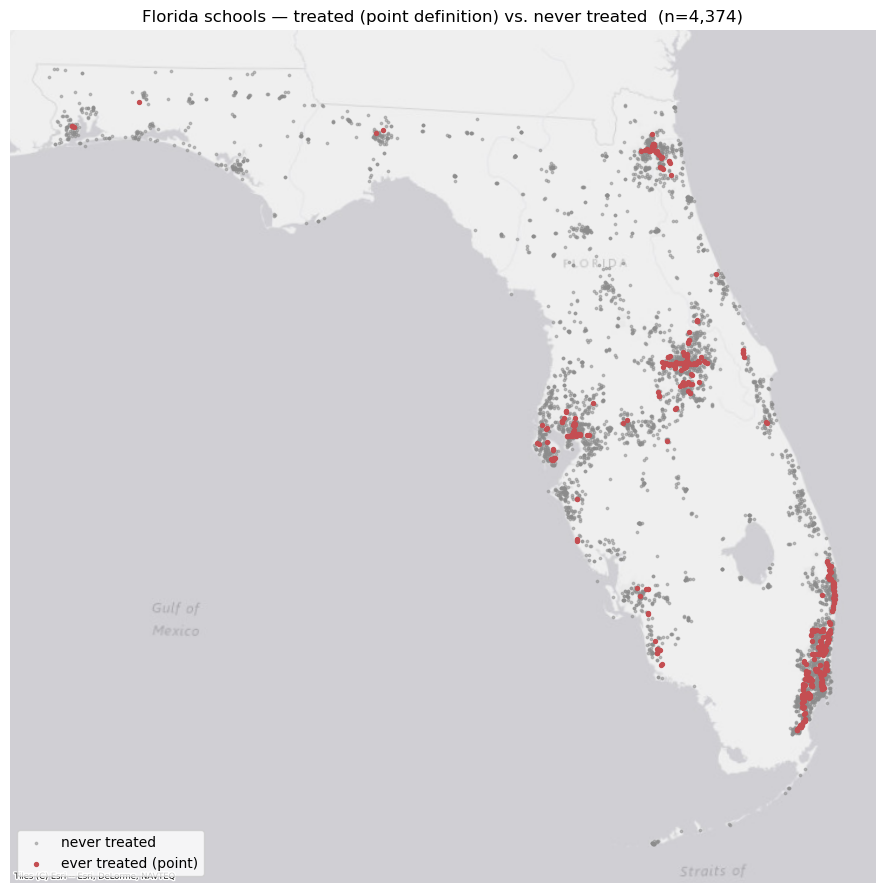

In [11]:
sc = panel.drop_duplicates("msid").dropna(subset=["geometry"])
sc = sc[~sc.geometry.is_empty]

fig, ax = plt.subplots(figsize=(9, 9))
sc[~sc["ever_treated_point"]].plot(ax=ax, markersize=3, color="#8c8c8c", alpha=0.5, label="never treated")
sc[sc["ever_treated_point"]].plot(ax=ax, markersize=8, color="#c44e52", label="ever treated (point)")
add_basemap(ax, crs=sc.crs)
ax.set_axis_off()
ax.legend(loc="lower left")
ax.set_title(f"Florida schools — treated (point definition) vs. never treated  (n={len(sc):,})")
fig.tight_layout()
savefig(fig, "panel_treated_schools_statewide.png")
plt.show()


Same footprint as `barriers.ipynb`'s statewide inventory map: treated schools cluster in
the three big urban corridors (South-East Florida, Metro Orlando, Tampa Bay) where the
noise-barrier inventory itself is concentrated — the treatment is not spread evenly across
the state, so any specification should expect the identifying variation to be
geographically clustered too.

## 7. Panel balance

wrote output/figures/florida/panel_schools_per_year_ela.png


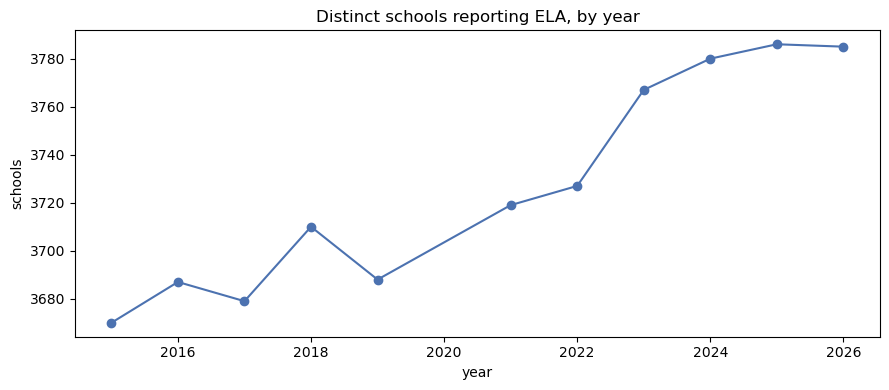

schools reporting ELA in every year 2015-2026: 3257
schools reporting ELA in at least one year:     4313


In [12]:
ela = panel[panel["subject_label"] == "English Language Arts"]
schools_per_year = ela.groupby("year")["msid"].nunique()

fig, ax = plt.subplots(figsize=(9, 4))
schools_per_year.plot(ax=ax, marker="o", color="#4c72b0")
ax.set_title("Distinct schools reporting ELA, by year")
ax.set_xlabel("year")
ax.set_ylabel("schools")
fig.tight_layout()
savefig(fig, "panel_schools_per_year_ela.png")
plt.show()

always_present = set(ela.loc[ela["year"] == 2015, "msid"])
for y in sorted(ela["year"].unique()):
    always_present &= set(ela.loc[ela["year"] == y, "msid"])
ever_present = ela["msid"].unique()
print(f"schools reporting ELA in every year 2015-2026: {len(always_present)}")
print(f"schools reporting ELA in at least one year:     {len(ever_present)}")


Pooling across all ELA grades (03-08, any grade counts as "present") gives a larger always-/ever-present count than `assessments.ipynb`'s own panel-shape check, which tracks grade-05 ELA only (~1,900 always-present / ~2,700 ever-present there) — the two are consistent, not contradictory: a school missing grade 5 in a given year can still report ELA for grades 3, 4, 6, 7 or 8, so the any-grade count is mechanically higher. Either way the panel is unbalanced, inherited unchanged from the assessments source through the join.

## Summary

- **370,891 rows**, `(msid, grade, subject, year)` grain, no duplicate keys — 4,419
  distinct schools, 2015-2026 (2020 excluded).
- **Outcome** `z_mss`: mean 0 / SD ≈ 1 pooled, no drift across the FSA→FAST/B.E.S.T. scale
  break — the source notebook's standardisation survives the join. 332,778 rows carry a
  score; the rest is the assessments source's own 10.3% suppression.
- **Covariates**: CCD fields (enrollment, race/ethnicity, FRPL) 10-15% missing; CRDC-only
  fields (`pct_swd`, `pct_ell`, proficiency midpoints) ~65% missing, reflecting CRDC's
  sparser reporting cycle rather than a join defect.
- **Treatment** is carried as three nested definitions — `same_side` ⊆ `same_route` ⊆
  `point` — 198 / 262 / 455 ever-treated schools respectively. **Only 31% (point) to 32%
  (same_side) of ever-treated schools have their nearest wall built inside the panel
  window**; the rest are always-treated in-sample and carry no pre-period. This is the
  single most consequential fact for choosing an event-study estimation sample.
- **Geography**: treatment is concentrated in Florida's three major urban corridors, not
  spread statewide.
- **Panel shape**: unbalanced — 3,257 schools report ELA (any grade) every year,
  4,313 ever, inherited unchanged from the assessments source through the left join.
